# 8 Rainhas — Algoritmo Genético

Indivíduos como vetores de 8 inteiros e fitness pelo número de pares de rainhas que não se atacam (máximo 28), com seleção probabilística, crossover, mutação e gráfico da evolução do fitness.

**Técnica:** Algoritmo genético  
**Referência:** Russell & Norvig, *Inteligência Artificial* (AIMA)  
**Contexto:** disciplina de Inteligência Artificial — Análise e Desenvolvimento de Sistemas, FATEC Taubaté

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devcauas/agentes-ia/blob/main/notebooks/08-8-rainhas-algoritmo-genetico.ipynb)


  ALGORITMO GENÉTICO — 8 RAINHAS
  Tamanho da população : 100
  Taxa de mutação      : 5.0%
  Máximo de gerações   : 1000
  Elitismo             : Ativado
  Geração    1 | Melhor: 25/28 | Média: 19.76 | Indivíduo: [6, 3, 1, 5, 8, 2, 2, 7]
  Geração   50 | Melhor: 27/28 | Média: 21.52 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Geração  100 | Melhor: 27/28 | Média: 22.30 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Geração  150 | Melhor: 27/28 | Média: 21.75 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Geração  200 | Melhor: 27/28 | Média: 20.75 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Geração  250 | Melhor: 27/28 | Média: 21.32 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Geração  300 | Melhor: 27/28 | Média: 22.19 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Geração  350 | Melhor: 27/28 | Média: 21.79 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Geração  400 | Melhor: 27/28 | Média: 22.01 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Geração  450 | Melhor: 27/28 | Média: 22.20 | Indivíduo: [7, 3, 7, 2, 8, 6, 4, 1]
  Ger

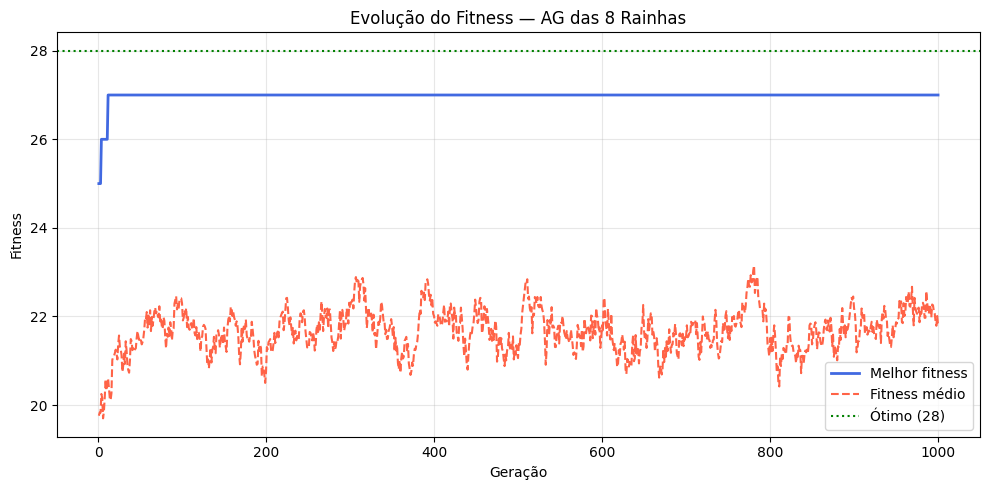


  Gráfico salvo em: evolucao_fitness.png


In [2]:
"""
============================================================
  Algoritmo Genético — Problema das 8 Rainhas
  Baseado em: IA Aula 8 — Algoritmos Genéticos
  Referência: Russell & Norvig (AIMA)
============================================================

REPRESENTAÇÃO:
  Cada indivíduo é uma lista de 8 inteiros [1..8].
  Posição i => coluna i+1; valor => linha da rainha.
  Exemplo: [2,4,6,8,3,1,7,5] significa:
    col1->linha2, col2->linha4, ..., col8->linha5

FITNESS:
  Conta pares de rainhas que NÃO se atacam.
  Máximo teórico: C(8,2) = 28 pares (solução perfeita).
  Conflito ocorre se duas rainhas estão na mesma linha
  ou na mesma diagonal (|linha_i - linha_j| == |col_i - col_j|).
"""

import random
import math
import matplotlib.pyplot as plt


# ============================================================
# 1. REPRESENTAÇÃO E INICIALIZAÇÃO
# ============================================================

def criar_individuo():
    """
    Gera um indivíduo aleatório: lista de 8 genes, cada um
    com valor entre 1 e 8 (linha da rainha em cada coluna).
    """
    return [random.randint(1, 8) for _ in range(8)]


def criar_populacao(tamanho):
    """
    Gera a população inicial com 'tamanho' indivíduos aleatórios.
    Equivale à etapa (a) da figura do AG na Aula 8.
    """
    return [criar_individuo() for _ in range(tamanho)]


# ============================================================
# 2. FUNÇÃO DE FITNESS (Função de Adaptação)
# ============================================================

def calcular_fitness(individuo):
    """
    Conta o número de pares de rainhas que NÃO se atacam.

    Lógica:
      - Para cada par (i, j) com i < j:
          * Mesma linha    => conflito se individuo[i] == individuo[j]
          * Mesma diagonal => conflito se abs(i-j) == abs(individuo[i]-individuo[j])
      - fitness = 28 - num_conflitos
      - fitness == 28 => solução perfeita (nenhum par em conflito)

    Nota: a Aula 8 usa exatamente essa métrica — número de pares
    NÃO atacantes, com valor 28 para a solução ótima.
    """
    conflitos = 0
    n = len(individuo)
    for i in range(n):
        for j in range(i + 1, n):
            # Conflito de linha
            if individuo[i] == individuo[j]:
                conflitos += 1
            # Conflito de diagonal
            elif abs(i - j) == abs(individuo[i] - individuo[j]):
                conflitos += 1
    return 28 - conflitos


def avaliar_populacao(populacao):
    """
    Retorna lista de fitness para toda a população.
    Equivale à etapa (b) da figura do AG — 'Função de adaptação'.
    """
    return [calcular_fitness(ind) for ind in populacao]


# ============================================================
# 3. SELEÇÃO POR ROLETA (Roulette Wheel Selection)
# ============================================================

def selecionar_por_roleta(populacao, fitness_lista):
    """
    Seleção proporcional ao fitness (roleta).

    Mecanismo:
      1. Calcula a soma total dos fitness.
      2. Cada indivíduo recebe uma fatia da roleta proporcional
         ao seu fitness: P(i) = fitness(i) / soma_total
      3. Gira a roleta (número aleatório [0, soma_total]).
      4. Retorna o indivíduo cuja fatia contém o número sorteado.

    Isso é equivalente às porcentagens mostradas na etapa (b)
    da figura do AG na Aula 8 (ex: 31%, 29%, 26%, 14%).
    """
    soma_total = sum(fitness_lista)

    # Caso degenerado: todos com fitness zero
    if soma_total == 0:
        return random.choice(populacao)

    # Gira a roleta
    ponto = random.uniform(0, soma_total)
    acumulado = 0
    for individuo, fitness in zip(populacao, fitness_lista):
        acumulado += fitness
        if acumulado >= ponto:
            return individuo

    # Fallback de segurança
    return populacao[-1]


# ============================================================
# 4. CROSSOVER DE PONTO ÚNICO
# ============================================================

def crossover(pai1, pai2):
    """
    Crossover de ponto único (single-point crossover).

    Processo (fiel à Aula 8):
      1. Escolhe aleatoriamente um ponto de corte c em [1, 7].
      2. Filho1 = pai1[:c] + pai2[c:]
      3. Filho2 = pai2[:c] + pai1[c:]

    Exemplo com ponto de corte c=3:
      pai1 = [3,2,7,5,2,4,1,1]  => filho1 = [3,2,7 | 5,2,4,1,1] (pai2 parte dir)
      pai2 = [3,2,7,4,8,5,5,2]  => filho2 = [3,2,7 | 5,2,4,1,1] (pai1 parte dir)

    Esta operação permite combinar "blocos" úteis de genes que
    evoluíram de forma independente em cada pai — o coração
    do AG segundo Russell & Norvig.
    """
    ponto_corte = random.randint(1, len(pai1) - 1)
    filho1 = pai1[:ponto_corte] + pai2[ponto_corte:]
    filho2 = pai2[:ponto_corte] + pai1[ponto_corte:]
    return filho1, filho2


# ============================================================
# 5. MUTAÇÃO
# ============================================================

def mutar(individuo, taxa_mutacao=0.05):
    """
    Aplica mutação gene a gene com probabilidade 'taxa_mutacao'.

    Para cada gene (posição/coluna):
      - Com probabilidade taxa_mutacao: substitui por valor aleatório [1..8]
      - Caso contrário: mantém o gene original

    Equivale à etapa (e) da figura do AG na Aula 8.
    A mutação introduz diversidade genética e impede convergência
    prematura para máximos locais.
    """
    return [
        random.randint(1, 8) if random.random() < taxa_mutacao else gene
        for gene in individuo
    ]


# ============================================================
# 6. ELITISMO (Opcional — preserva o melhor indivíduo)
# ============================================================

def elitismo(populacao, fitness_lista, nova_populacao):
    """
    Preserva o melhor indivíduo da geração atual na nova população.
    Garante que o AG nunca perca a melhor solução encontrada.
    (Extensão prática ao modelo base da Aula 8.)
    """
    idx_melhor = fitness_lista.index(max(fitness_lista))
    nova_populacao[0] = populacao[idx_melhor][:]
    return nova_populacao


# ============================================================
# 7. ALGORITMO GENÉTICO PRINCIPAL
# ============================================================

def algoritmo_genetico(
    tamanho_populacao=100,
    taxa_mutacao=0.05,
    max_geracoes=1000,
    usar_elitismo=True,
    verbose=True
):
    """
    Implementação completa do Algoritmo Genético para as 8 Rainhas.
    Segue rigorosamente o pseudocódigo ALGORITMO-GENÉTICO da Aula 8:

        repita
          nova_populacao <- conjunto vazio
          para i = 1 até TAMANHO(populacao):
              x <- SELEÇÃO-ALEATÓRIA(populacao, FN-ADAPTA)
              y <- SELEÇÃO-ALEATÓRIA(populacao, FN-ADAPTA)
              filho <- REPRODUZ(x, y)
              se (pequena probabilidade): filho <- MUTAÇÃO(filho)
              adicionar filho a nova_populacao
          populacao <- nova_populacao
        até algum indivíduo estar adaptado o suficiente
        retornar o melhor indivíduo

    Retorna:
        melhor_individuo, melhor_fitness, geracao, historico_fitness
    """
    # --- Inicialização ---
    populacao = criar_populacao(tamanho_populacao)
    historico_melhor  = []
    historico_media   = []
    melhor_global     = None
    melhor_fitness_global = -1

    if verbose:
        print("=" * 60)
        print("  ALGORITMO GENÉTICO — 8 RAINHAS")
        print("=" * 60)
        print(f"  Tamanho da população : {tamanho_populacao}")
        print(f"  Taxa de mutação      : {taxa_mutacao:.1%}")
        print(f"  Máximo de gerações   : {max_geracoes}")
        print(f"  Elitismo             : {'Ativado' if usar_elitismo else 'Desativado'}")
        print("=" * 60)

    for geracao in range(1, max_geracoes + 1):

        # --- Avaliação (etapa b) ---
        fitness_lista = avaliar_populacao(populacao)

        # --- Estatísticas da geração ---
        melhor_fitness_geracao = max(fitness_lista)
        media_fitness_geracao  = sum(fitness_lista) / len(fitness_lista)
        idx_melhor = fitness_lista.index(melhor_fitness_geracao)

        historico_melhor.append(melhor_fitness_geracao)
        historico_media.append(media_fitness_geracao)

        # Atualiza melhor global
        if melhor_fitness_geracao > melhor_fitness_global:
            melhor_fitness_global = melhor_fitness_geracao
            melhor_global = populacao[idx_melhor][:]

        # Log periódico
        if verbose and (geracao % 50 == 0 or geracao == 1 or melhor_fitness_geracao == 28):
            print(f"  Geração {geracao:4d} | "
                  f"Melhor: {melhor_fitness_geracao:2d}/28 | "
                  f"Média: {media_fitness_geracao:.2f} | "
                  f"Indivíduo: {populacao[idx_melhor]}")

        # --- Critério de parada: solução ótima ---
        if melhor_fitness_geracao == 28:
            if verbose:
                print(f"\n  *** SOLUÇÃO ÓTIMA ENCONTRADA na geração {geracao}! ***")
            return melhor_global, melhor_fitness_global, geracao, historico_melhor, historico_media

        # --- Reprodução: nova população (etapas c, d, e) ---
        nova_populacao = []

        for _ in range(tamanho_populacao):
            # Seleção por roleta (etapa c)
            pai1 = selecionar_por_roleta(populacao, fitness_lista)
            pai2 = selecionar_por_roleta(populacao, fitness_lista)

            # Crossover de ponto único (etapa d) — REPRODUZ(x, y)
            filho1, filho2 = crossover(pai1, pai2)

            # Escolhe um dos dois filhos (versão clássica: 1 filho por par)
            filho = random.choice([filho1, filho2])

            # Mutação (etapa e)
            filho = mutar(filho, taxa_mutacao)

            nova_populacao.append(filho)

        # Elitismo: preserva o melhor
        if usar_elitismo:
            nova_populacao = elitismo(populacao, fitness_lista, nova_populacao)

        populacao = nova_populacao

    # --- Critério de parada: máximo de gerações atingido ---
    if verbose:
        print(f"\n  Máximo de gerações ({max_geracoes}) atingido.")
        print(f"  Melhor fitness alcançado: {melhor_fitness_global}/28")

    return melhor_global, melhor_fitness_global, max_geracoes, historico_melhor, historico_media


# ============================================================
# 8. VISUALIZAÇÃO
# ============================================================

def exibir_tabuleiro(individuo):
    """
    Exibe o tabuleiro de xadrez com as 8 rainhas posicionadas.
    Q = rainha, . = casa vazia.
    """
    print("\n  Tabuleiro (Q = rainha):")
    print("  +" + "---+" * 8)
    for linha in range(1, 9):
        row = "  |"
        for coluna in range(8):
            if individuo[coluna] == linha:
                row += " Q |"
            else:
                row += " . |"
        print(row)
        print("  +" + "---+" * 8)
    colunas = "  ".join([str(i+1) for i in range(8)])
    print(f"    {colunas}  (colunas)")


def plotar_evolucao(historico_melhor, historico_media, geracao_final):
    """
    Plota a curva de evolução do fitness ao longo das gerações.
    """
    geracoes = list(range(1, len(historico_melhor) + 1))

    plt.figure(figsize=(10, 5))
    plt.plot(geracoes, historico_melhor, label="Melhor fitness", color="royalblue", linewidth=2)
    plt.plot(geracoes, historico_media,  label="Fitness médio",  color="tomato",    linewidth=1.5, linestyle="--")
    plt.axhline(y=28, color="green", linestyle=":", linewidth=1.5, label="Ótimo (28)")
    plt.xlabel("Geração")
    plt.ylabel("Fitness")
    plt.title("Evolução do Fitness — AG das 8 Rainhas")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("evolucao_fitness.png", dpi=150)
    plt.show()
    print("\n  Gráfico salvo em: evolucao_fitness.png")


# ============================================================
# 9. PONTO DE ENTRADA
# ============================================================

if __name__ == "__main__":

    random.seed(42)   # Reprodutibilidade (remova para resultados variados)

    resultado = algoritmo_genetico(
        tamanho_populacao = 100,
        taxa_mutacao      = 0.05,
        max_geracoes      = 1000,
        usar_elitismo     = True,
        verbose           = True
    )

    melhor, fitness, geracao, hist_melhor, hist_media = resultado

    # --- Saída final ---
    print("\n" + "=" * 60)
    print("  RESULTADO FINAL")
    print("=" * 60)
    print(f"  Cromossomo   : {melhor}")
    print(f"  Fitness      : {fitness}/28")
    print(f"  Gerações     : {geracao}")
    print(f"  Solução ótima: {'SIM' if fitness == 28 else 'NÃO (melhor encontrada)'}")

    exibir_tabuleiro(melhor)
    plotar_evolucao(hist_melhor, hist_media, geracao)